<a href="https://colab.research.google.com/github/rpaulos/yolov8-seg-aruco-pothole-measurement/blob/main/BestAruCoMarkers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Augmented Reality University of Cordoba


## ArUco Markers Definition
An ArUco marker is a square binary fiducial marker used in computer vision to determine the position and orientation of an object relative to a camera

## Part 1: SetUp and Configuration of ArUco Markers

### 1.1.1 Install Dependencies

In [1]:
!pip install -q ultralytics opencv-contrib-python

CUSTOM_ZIP = "/content/ultralytics-kaggle3.zip"

### 1.1.2 Install: Custom Ultralytics with Coordinate Attention

In [2]:
import shutil
from pathlib import Path

CUSTOM_REPO = Path("/content/ultralytics-custom")

if CUSTOM_REPO.exists():
    shutil.rmtree(CUSTOM_REPO)

shutil.unpack_archive(CUSTOM_ZIP, CUSTOM_REPO)

print("Extracted to:", CUSTOM_REPO)
print("pyproject.toml exists:", (CUSTOM_REPO / "pyproject.toml").exists())

Extracted to: /content/ultralytics-custom
pyproject.toml exists: True


In [3]:
%cd /content/ultralytics-custom
!pip uninstall -y ultralytics
!pip install -e . --no-deps
%cd /content

/content/ultralytics-custom
Found existing installation: ultralytics 8.4.117
Uninstalling ultralytics-8.4.117:
  Successfully uninstalled ultralytics-8.4.117
Obtaining file:///content/ultralytics-custom
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.4.117-0.editable-py3-none-any.whl size=4920 sha256=f1c10835d0f261395a8184d6c1085d9d77cf06efb784cb16c00443c32f024a18
  Stored in directory: /tmp/pip-ephem-wheel-cache-zzcxihnz/wheels/1c/2a/95/2ca0c50ede365ccd61c924cd00aef5f971a52d2c0e8cd7827c
Successfully built ultralytics
/content


### 1.1.3 Verify if Custom Ultralytics Loaded Correctly

Confirms Python is using the custom package (not a cached/plain version) and that CoordinateAttention is importable before loading best.pt.

In [4]:
import sys
import ultralytics
from ultralytics.nn.modules import CoordinateAttention

CUSTOM_REPO_STR = str(CUSTOM_REPO)
if CUSTOM_REPO_STR not in sys.path:
    sys.path.insert(0, CUSTOM_REPO_STR)

print("Ultralytics loaded from:", ultralytics.__file__)
print("CoordinateAttention:", CoordinateAttention)

Ultralytics loaded from: /content/ultralytics-custom/ultralytics/__init__.py
CoordinateAttention: <class 'ultralytics.nn.modules.block.CoordinateAttention'>


### 1.2 Imports

In [5]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import drive

### 1.3 Mount Google Drive

In [6]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.4 Configuration
All paths and physical measurements used throughout the notebook

In [7]:
# ArUco dictionary
aruco_dict = cv2.aruco.getPredefinedDictionary(
    cv2.aruco.DICT_4X4_50
)

# Generate 4 markers
for marker_id in range(4):

    marker = cv2.aruco.generateImageMarker(
        aruco_dict,
        marker_id,
        1000
    )

    filename = f"aruco_marker_{marker_id}.png"

    cv2.imwrite(filename, marker)

    print(f"Saved: {filename}")

Saved: aruco_marker_0.png
Saved: aruco_marker_1.png
Saved: aruco_marker_2.png
Saved: aruco_marker_3.png


#### 1.4.1 Paths

In [8]:
TEST_IMAGE = "Pothole3"

FILE_TYPE = "png"

CLASS_NUM = 0

OBJECT_LABEL = "Pothole"

In [9]:
IMAGE_PATH = f"/content/drive/MyDrive/thesis/Test_Images/{TEST_IMAGE}.{FILE_TYPE}"
# MODEL_PATH = "/content/drive/MyDrive/thesis/yolov8n-seg.pt"
MODEL_PATH = "/content/best.pt"
MARKER_OUTPUT_DIRECTORY = "/content/drive/MyDrive/thesis/ArUcoMarkers"

#### 1.4.2 ArUco Marker SetUp

In [10]:
ARUCO_DICT_TYPE = cv2.aruco.DICT_4X4_50
NUM_MARKERS_TO_GENERATE = 4
MARKER_IDS = [0, 1, 2, 3]
MARKER_SIZE_CM = 7.0

#### 1.4.3 Object Label

In [11]:
# # This is only temporary. Change this when
# # using the actual model and not the pretrained
# # COCO model

# OBJECT_LABEL = "notebook"

## Part 2: Generate ArUco Markers

Generated four corner ArUco markers  (IDs 0-3) as image files saved to google drive. After the initial run of **Part 2: Generate ArUco Markers** this section can be skipped on future runs.

### 2.1 Generate and Save AruCo Markers

In [12]:
os.makedirs(MARKER_OUTPUT_DIRECTORY, exist_ok=True)

aruco_dict = cv2.aruco.getPredefinedDictionary(ARUCO_DICT_TYPE)

MARKER_PIXELS = 400

for marker_id in MARKER_IDS:
    marker_img = cv2.aruco.generateImageMarker(
        aruco_dict,
        marker_id,
        MARKER_PIXELS
    )

    out_path = os.path.join(MARKER_OUTPUT_DIRECTORY, f"marker_{marker_id}.png")
    cv2.imwrite(out_path, marker_img)

    print(f"Saved: {out_path} -> {out_path}")

Saved: /content/drive/MyDrive/thesis/ArUcoMarkers/marker_0.png -> /content/drive/MyDrive/thesis/ArUcoMarkers/marker_0.png
Saved: /content/drive/MyDrive/thesis/ArUcoMarkers/marker_1.png -> /content/drive/MyDrive/thesis/ArUcoMarkers/marker_1.png
Saved: /content/drive/MyDrive/thesis/ArUcoMarkers/marker_2.png -> /content/drive/MyDrive/thesis/ArUcoMarkers/marker_2.png
Saved: /content/drive/MyDrive/thesis/ArUcoMarkers/marker_3.png -> /content/drive/MyDrive/thesis/ArUcoMarkers/marker_3.png


### 2.2 View Generated ArUco Markers

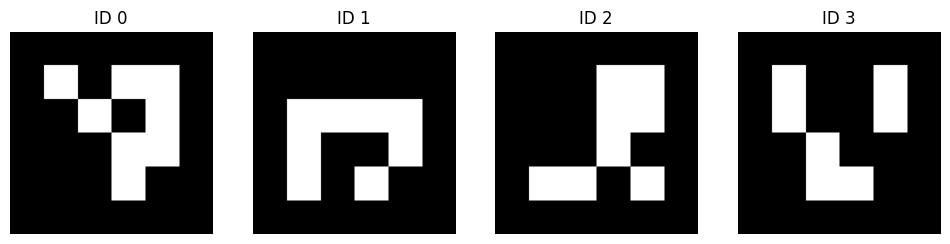

In [13]:
fig, axes = plt.subplots(1, len(MARKER_IDS), figsize=(12, 3))

for ax, marker_id in zip(axes, MARKER_IDS):
    marker_img = cv2.imread(os.path.join(MARKER_OUTPUT_DIRECTORY, f"marker_{marker_id}.png"))
    ax.imshow(cv2.cvtColor(marker_img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"ID {marker_id}")
    ax.axis("off")

plt.show()

### 2.3 Printing Instructions

*   Print each marker using the MARKER_SIZE_CM (5.0cm) per side (5 by 5).
*   Set scale to 100%; do not use "fit to page" as this will distort the size of the markers.
*   Cut the markers out. The markers uses each own known size so you can place each anywhere around the object.
*   Keep all 4 markers flat, unobstructed, and fully in-frame when photographing your object.




## Part 3: Load YOLOv8n-Seg Model

In [14]:
model = YOLO(MODEL_PATH)
print(model.names)

{0: 'pothole'}


## Part 4: Run Segmentation on the Test Image


image 1/1 /content/drive/MyDrive/thesis/Test_Images/Pothole3.png: 640x480 1 pothole, 1823.9ms
Speed: 10.4ms preprocess, 1823.9ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 480)


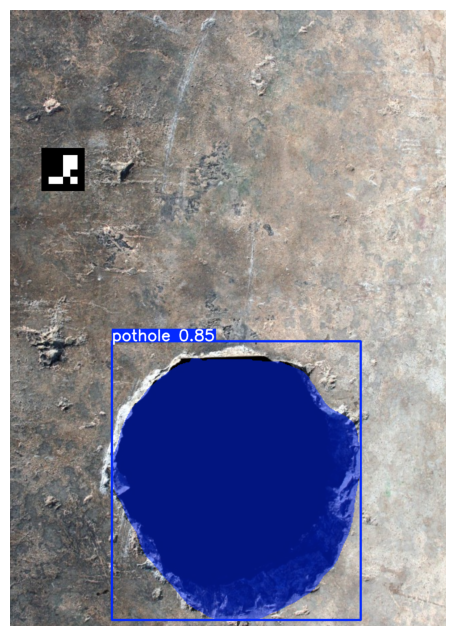

In [15]:
results = model(IMAGE_PATH, classes=[CLASS_NUM])

annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Part 5: Detect ArUco Markers and Calibrate Scale

### 5.1 Detect Markers in the Image

In [16]:
image = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)

corners, ids, rejected = detector.detectMarkers(gray)

if ids is None:
  raise RuntimeError("No markers detected. Try a different image. Make sure at least one ArUco marker is visible and unobstructed.")

print("Detected marker IDs: ", ids.flatten())

Detected marker IDs:  [2]


### 5.2 Visualize Detected Markers

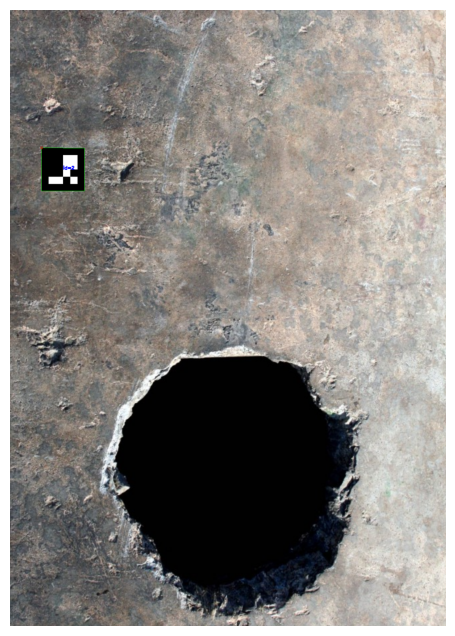

In [17]:
aruco_output = image.copy()
cv2.aruco.drawDetectedMarkers(aruco_output, corners, ids)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(aruco_output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### 5.3 Compute Pixel-to-Centimeter Scale from Marker Size

In [18]:
marker_scales = []

for corner in corners:
  pts = corner[0]

  side_lengths_px = [
      np.linalg.norm(pts[i] - pts[(i + 1) % 4])
      for i in range(4)
  ]

  avg_side_px = np.mean(side_lengths_px)
  marker_scales.append(MARKER_SIZE_CM / avg_side_px)

SCALE_CM_PER_PX = np.mean(marker_scales)

print(f"Scale estimates per marker (cm/px): {[f'{s:.6f}' for s in marker_scales]}")
print(f"Averaged scale: {SCALE_CM_PER_PX:.6f} cm/pixel")


Scale estimates per marker (cm/px): ['0.050269']
Averaged scale: 0.050269 cm/pixel


## Part 6: Extract Segmentation Mask

In [19]:
result = results[0]

if result.masks is None:
    raise RuntimeError("YOLO detected the object, but no segmentation mask was returned.")

print("Number of segmented objects:", len(result.masks.data))

# NOTE: this pipeline measures the FIRST detected mask (index 0).
# If your model may detect multiple objects, add logic here to select
# the right one (e.g. by class ID or largest mask area) before continuing.
mask = result.masks.data[0].cpu().numpy()

image_height, image_width = image.shape[:2]
mask = cv2.resize(mask, (image_width, image_height), interpolation=cv2.INTER_NEAREST)
mask = mask > 0.5

Number of segmented objects: 1


Part 7: Measure the Object

Converts the mask's pixel dimensions and area into real-world centimeters using the calibrated scale from Part 5.

In [20]:
ys, xs = np.where(mask)

if len(xs) == 0:
    raise RuntimeError("The segmentation mask is empty — nothing to measure.")

x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()

width_px = x_max - x_min
height_px = y_max - y_min

width_cm = width_px * SCALE_CM_PER_PX
height_cm = height_px * SCALE_CM_PER_PX

area_pixels = np.sum(mask)
area_cm2 = area_pixels * (SCALE_CM_PER_PX ** 2)

print(f"Estimated width:  {width_cm:.2f} cm")
print(f"Estimated height: {height_cm:.2f} cm")
print(f"Estimated area:   {area_cm2:.2f} cm²")

Estimated width:  37.85 cm
Estimated height: 42.68 cm
Estimated area:   1252.00 cm²


## Part 8: Final Visualization

In [21]:
output = image.copy()

# Segmentation contour
mask_uint8 = (mask.astype(np.uint8) * 255)
contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(output, contours, -1, (0, 255, 0), 3)

# Bounding box
cv2.rectangle(output, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

# ArUco markers
cv2.aruco.drawDetectedMarkers(output, corners, ids)

# Measurement labels
text_lines = [
    OBJECT_LABEL,
    f"Width: {width_cm:.2f} cm",
    f"Height: {height_cm:.2f} cm",
    f"Area: {area_cm2:.2f} cm2"
]

text_x = x_min
text_y = max(y_min - 80, 30)

for i, text in enumerate(text_lines):
    cv2.putText(
        output,
        text,
        (text_x, text_y + i * 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (0, 255, 0),
        2,
        cv2.LINE_AA
    )

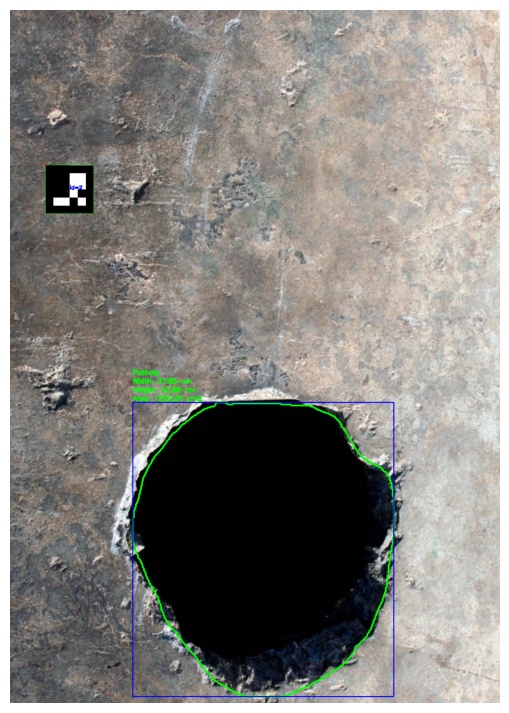

In [22]:
plt.figure(figsize=(14, 9))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()